# Fase 7: Modelo Cinemático (Telemetría inercial y TinyML)

**Autor:** Andoni Cabrera Fernández

**Descripción técnica:** En este cuaderno se desarrolla un sistema de detección de anomalías en la conducción basado en la telemetría del vehículo (acelerómetro y giroscopio). Este enfoque complementa el análisis de visión artificial previamente desarrollado, proporcionando robustez frente a posibles oclusiones o fallos del sensor óptico.

Se procesa el *Driving Behavior Dataset* aplicando ingeniería de características (*Feature Engineering*). Específicamente, se emplean ventanas temporales móviles de 3 segundos y se calcula la magnitud vectorial para garantizar la invarianza espacial de las lecturas del sensor. El modelo predictivo implementado es un Bosque Aleatorio (*Random Forest*), seleccionado y parametrizado para mantener la eficiencia computacional exigida en un despliegue sobre hardware de recursos limitados (*TinyML*).

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Conectar con Google Drive
drive.mount('/content/drive')
print("\nEntorno configurado correctamente.")

Mounted at /content/drive

Entorno configurado correctamente.


## 1. Carga del conjunto de datos y preprocesamiento base

In [2]:
# Rutas (Ajusta la carpeta según tu Drive)
RUTA_TRAIN = '/content/drive/MyDrive/Telemetría/train_motion_data.csv'
RUTA_TEST = '/content/drive/MyDrive/Telemetría/test_motion_data.csv'

# Carga y unificación de los CSV para partición propia
df_train = pd.read_csv(RUTA_TRAIN)
df_test = pd.read_csv(RUTA_TEST)
df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all.columns = df_all.columns.str.strip()

features = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
target = 'Class'

# Mapeo a valores numéricos (0: Normal, 1: Slow, 2: Aggressive)
# La clase "Aggressive" simula los espasmos o volantazos característicos del micro-sueño
mapeo_clases = {'NORMAL': 0, 'SLOW': 1, 'AGGRESSIVE': 2}
df_all['Label'] = df_all[target].map(mapeo_clases)
df_all = df_all.dropna(subset=features + ['Label'])

print(f"Conjunto de datos cargado. Total de muestras sin procesar: {len(df_all)}")
display(df_all.head())

Conjunto de datos cargado. Total de muestras sin procesar: 6728


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp,Label
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629,0
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630,0
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630,0
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631,0
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631,0


## 2. Ingeniería de características (Magnitud vectorial y ventanas móviles)

In [3]:
# 1. Invarianza Espacial: Magnitud Vectorial (Fuerza total sin importar la orientación del sensor)
df_all['Acc_Mag'] = np.sqrt(df_all['AccX']**2 + df_all['AccY']**2 + df_all['AccZ']**2)
df_all['Gyro_Mag'] = np.sqrt(df_all['GyroX']**2 + df_all['GyroY']**2 + df_all['GyroZ']**2)

features_ampliadas = features + ['Acc_Mag', 'Gyro_Mag']

def crear_ventana_temporal(df, window_size=6):
    """ window_size=6 equivale a 3 segundos (muestreo a 2Hz) """
    dfs = []
    for c in df['Class'].unique():
        sub_df = df[df['Class'] == c].copy()

        # Extracción estadística
        for f in features_ampliadas:
            sub_df[f'{f}_mean'] = sub_df[f].rolling(window_size).mean()
            sub_df[f'{f}_std']  = sub_df[f].rolling(window_size).std()
            sub_df[f'{f}_max']  = sub_df[f].rolling(window_size).max()
            sub_df[f'{f}_min']  = sub_df[f].rolling(window_size).min()

        dfs.append(sub_df.dropna())
    return pd.concat(dfs, ignore_index=True)

print("Aplicando ventanas temporales (3 segundos)...")
df_win = crear_ventana_temporal(df_all, window_size=6)

nuevas_features = [c for c in df_win.columns if any(f in c for f in features_ampliadas) and '_' in c]
X = df_win[nuevas_features].values
y = df_win['Label'].values

print(f"Transformación completada. Dataset final: {len(X)} muestras con {X.shape[1]} características.")

Aplicando ventanas temporales (3 segundos)...
Transformación completada. Dataset final: 6713 muestras con 34 características.


## 3. Entrenamiento y evaluación del modelo predictivo

Exactitud global (Accuracy): 82.65%

                precision    recall  f1-score   support

    NORMAL (0)       0.89      0.71      0.79       439
      SLOW (1)       0.75      0.94      0.83       520
AGGRESSIVE (2)       0.91      0.80      0.85       384

      accuracy                           0.83      1343
     macro avg       0.85      0.82      0.83      1343
  weighted avg       0.84      0.83      0.83      1343



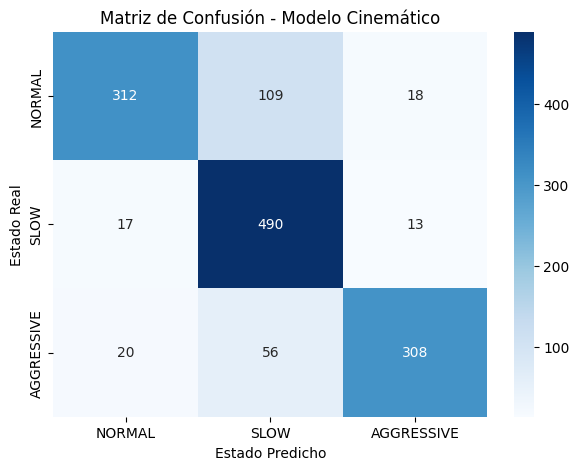

['/content/drive/MyDrive/Telemetría/experto_cinematico.pkl']

In [4]:
# División estricta (Hold-out Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Random Forest acotado para sistemas integrados
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# Predicción y Evaluación
y_pred = modelo_rf.predict(X_test)
precision = accuracy_score(y_test, y_pred)

print(f"Exactitud global (Accuracy): {precision * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['NORMAL (0)', 'SLOW (1)', 'AGGRESSIVE (2)']))

# Visualización
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'SLOW', 'AGGRESSIVE'],
            yticklabels=['NORMAL', 'SLOW', 'AGGRESSIVE'])
plt.title('Matriz de Confusión - Modelo Cinemático')
plt.ylabel('Estado Real'); plt.xlabel('Estado Predicho')
plt.show()

# Exportar modelo
joblib.dump(modelo_rf, '/content/drive/MyDrive/Telemetría/experto_cinematico.pkl')